# 01 - Exploratory Data Analysis/Feature Engineering

The goal of this notebook is to understand the raw FPL data, identify what's usable as features vs. what leaks, and produce a modeling-ready dataset.

Constraint: When predicting GW_n, we can only use information available before kickoff. Same-gameweek performance stats must be converted into lagged features from prior GWs.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
RAW = Path("../data/raw")
SEASONS = ["2021-22", "2022-23", "2023-24"]

## 1: Load & Combine Seasons

We restrict to the **36 columns shared across all three seasons** so the dataset is uniform. Season-specific columns (`expected_goals`, `starts`, etc.) are only available from 22/23 onward and would create structural missingness.

In [ ]:
frames = []
for season in SEASONS:
    df = pd.read_csv(RAW / season / "merged_gw.csv", low_memory=False)
    frames.append(df)

# find shared columns
shared_cols = sorted(set.intersection(*(set(f.columns) for f in frames)))

for frame, season in zip(frames, SEASONS):
    frame["season"] = season

raw = pd.concat([f[shared_cols + ["season"]] for f in frames], ignore_index=True)

print(f"Combined: {raw.shape[0]:,} rows × {raw.shape[1]} cols")
print(f"Seasons:  {raw['season'].value_counts().to_dict()}")

Combined: 81,677 rows × 37 cols
Seasons:  {'2023-24': 29725, '2022-23': 26505, '2021-22': 25447}


In [5]:
raw.dtypes

GW                     int64
assists                int64
bonus                  int64
bps                    int64
clean_sheets           int64
creativity           float64
element                int64
fixture                int64
goals_conceded         int64
goals_scored           int64
ict_index            float64
influence            float64
kickoff_time             str
minutes                int64
name                     str
opponent_team          int64
own_goals              int64
penalties_missed       int64
penalties_saved        int64
position                 str
red_cards              int64
round                  int64
saves                  int64
selected               int64
team                     str
team_a_score           int64
team_h_score           int64
threat               float64
total_points           int64
transfers_balance      int64
transfers_in           int64
transfers_out          int64
value                  int64
was_home                bool
xP            

## 2: Column Classification

Before looking at distributions, we need to sort every column into one of four buckets to avoid data leakage.

The four buckets are:
1. identifiers (define who/when, not direct features)
2. the target variable
3. pre-kickoff variables (known before GW_n)
4. post-kickoff variables (known after GW_n)

We also have access to the official FPL prediction of points, which will serve as a benchmark

In [8]:
ID_COLS = ["element", "name", "fixture", "kickoff_time", "round", "GW", "season"]

TARGET = "total_points"

PRE_KICKOFF = ["was_home", "opponent_team", "value", "selected", "transfers_in", "transfers_out", "transfers_balance", "position", "team"]

POST_KICKOFF = ["minutes", "goals_scored", "assists", "clean_sheets", "goals_conceded", "saves", "bonus", "bps", "own_goals", "penalties_missed",
                "penalties_saved", "red_cards", "yellow_cards", "influence", "creativity", "threat", "ict_index"]

# Match result
MATCH_RESULT = ["team_a_score", "team_h_score"]

# FPL's own pre-match prediction
FPL_PREDICTION = ["xP"]

## 3: Target Variable: total_points

In [9]:
raw[TARGET].describe().round(2)

count    81677.00
mean         1.16
std          2.37
min         -4.00
25%          0.00
50%          0.00
75%          1.00
max         26.00
Name: total_points, dtype: float64

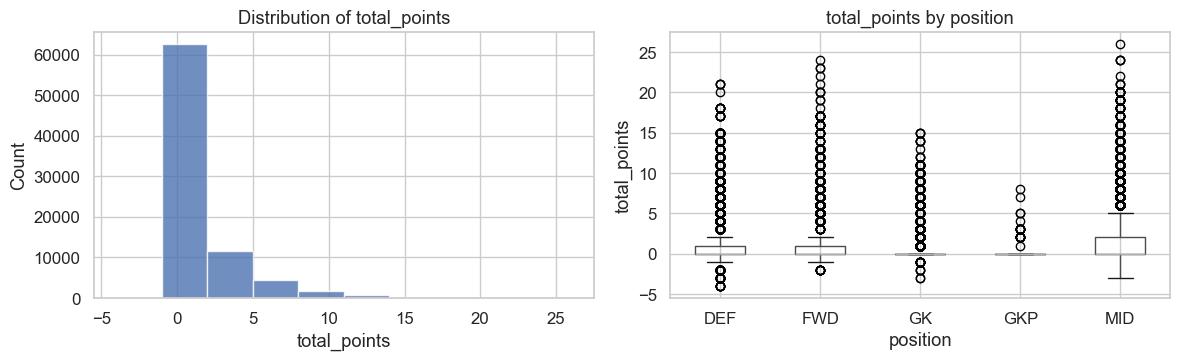

61.57% of rows have 0 points (didn't play)
87.51% of rows have <= 2 points


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# distribution 
axes[0].hist(raw[TARGET], edgecolor="white", alpha=0.8)
axes[0].set_xlabel("total_points")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of total_points")

# by position
raw.boxplot(column=TARGET, by="position", ax=axes[1])
axes[1].set_title("total_points by position")
axes[1].set_ylabel("total_points")
plt.suptitle("")
plt.tight_layout()
plt.show()

pct_zero = (raw[TARGET] == 0).mean() * 100
pct_lte2 = (raw[TARGET] <= 2).mean() * 100
print(f"{pct_zero:.2f}% of rows have 0 points (didn't play)")
print(f"{pct_lte2:.2f}% of rows have <= 2 points")

The target is heavily concentrated at low values. A large fraction of observations are 0 (player didn't feature) or 1–2 (came on briefly). This means:

1. **The median prediction is ~2 points**: any model that just predicts 2 for everyone will look decent on MAE.
2. **The interesting signal is in the tail**: predicting who will score 8+ points is where the value is.
3. **We should think about whether to filter out 0-minute rows** for modeling (predicting points for a player we already know won't play is meaningless).

## 4: Minutes Played & the Zero Problem

In [14]:
minutes_breakdown = pd.cut(
    raw["minutes"], bins=[-1, 0, 1, 60, 89, 90],
    labels=["0 (DNP)", "1", "2-60", "61-89", "90"]
).value_counts(normalize=True).sort_index() * 100

minutes_breakdown.round(1)

minutes
0 (DNP)    59.3
1           1.0
2-60       11.0
61-89       7.5
90         21.3
Name: proportion, dtype: float64

## 5: Pre-Kickoff Features

Columns we can use directly.

In [15]:
raw[PRE_KICKOFF].describe().round(2)

,opponent_team,value,selected,transfers_in,transfers_out,transfers_balance
count,81677.00,81677.00,81677.00,81677.00,81677.00,81677.00
mean,10.50,49.37,211216.93,15031.96,13356.78,1674.74
std,5.77,11.32,625308.01,63314.26,55089.25,74171.35
min,1.00,36.00,0.00,0.00,0.00,-2693401.00
25%,5.00,44.00,3852.00,22.00,79.00,-928.00
50%,10.00,45.00,18102.00,253.00,672.00,-41.00
75%,15.00,52.00,112476.00,3573.00,5916.00,35.00
max,20.00,145.00,9582624.00,2104464.00,2747279.00,1983733.00


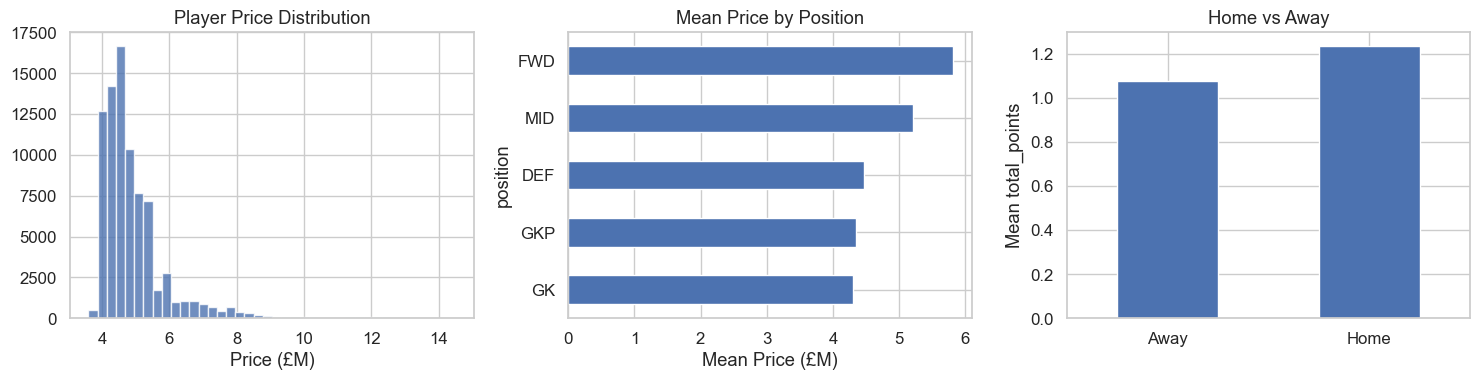

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw["value"] / 10, bins=40, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Price (£M)")
axes[0].set_title("Player Price Distribution")

raw.groupby("position")["value"].mean().div(10).sort_values().plot.barh(ax=axes[1])
axes[1].set_xlabel("Mean Price (£M)")
axes[1].set_title("Mean Price by Position")

home_away = raw.groupby("was_home")[TARGET].mean()
home_away.index = ["Away", "Home"]
home_away.plot.bar(ax=axes[2], rot=0)
axes[2].set_ylabel("Mean total_points")
axes[2].set_title("Home vs Away")

plt.tight_layout()
plt.show()

## 6: Post-Kickoff Stats (Lag Features)

Can't be used for the current GW but will be used for our lag features.

In [17]:
# correlation of same-GW stats with total_points
corr_with_target = raw[POST_KICKOFF + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
corr_with_target.round(3)

bps                 0.910
influence           0.828
ict_index           0.772
bonus               0.752
goals_scored        0.682
minutes             0.640
threat              0.578
clean_sheets        0.577
creativity          0.482
assists             0.462
goals_conceded      0.202
saves               0.165
yellow_cards        0.085
penalties_saved     0.080
penalties_missed    0.018
own_goals          -0.026
red_cards          -0.043
Name: total_points, dtype: float64

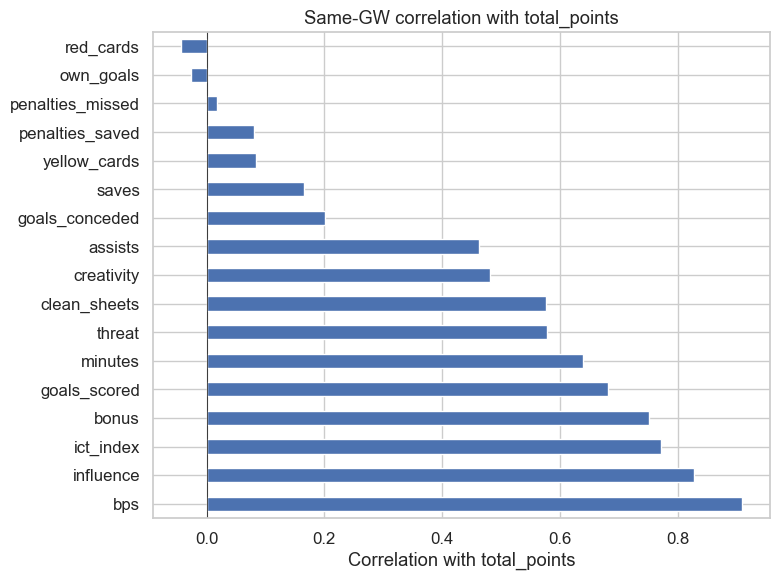

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.plot.barh(ax=ax)
ax.set_xlabel(f"Correlation with {TARGET}")
ax.set_title("Same-GW correlation with total_points")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 7: Correlation Heatmap

Check for multicollinearity among the post-kickoff stats. High correlation between features signals opportunities for PCA later.

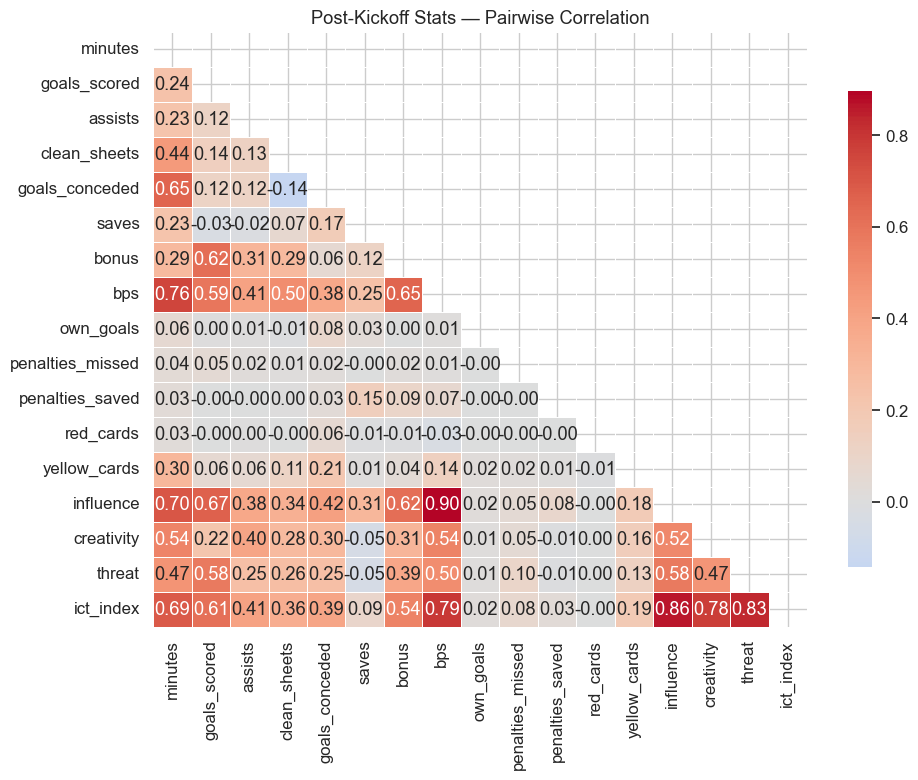

In [20]:
corr_matrix = raw[POST_KICKOFF].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Post-Kickoff Stats — Pairwise Correlation")
plt.tight_layout()
plt.show()

## 8: Missing Values & Data Quality

In [21]:
missing = raw.isnull().sum()
missing[missing > 0].sort_values(ascending=False) if missing.any() else print("No missing values.")

No missing values.


In [23]:
# check for anomalies
checks = {
    "negative minutes": (raw["minutes"] < 0).sum(),
    "minutes > 90": (raw["minutes"] > 90).sum(),
    "total_points < -10": (raw[TARGET] < -10).sum(),
    "duplicate (name, season, GW)": raw.duplicated(subset=["name", "season", "GW"]).sum(),
}
pd.Series(checks, name="count")

negative minutes                   0
minutes > 90                       0
total_points < -10                 0
duplicate (name, season, GW)    4819
Name: count, dtype: int64

---



# Data Processing Pipeline

Now that we understand the data, we'll build the processed dataset. The pipeline:

1. Aggregate double gameweek rows
2. Sort by player and time
3. Build lag & rolling features from post-kickoff stats
4. Encode categorical variables (position, home/away)
5. Drop rows with insufficient history
6. Drop all same-GW leakage columns
7. Save

### 8.0: Aggregate Double Gameweeks

4,819 rows are duplicates where a player had two fixtures in the same GW. We collapse these into one row per player per GW:

- Sum performance stats (points, goals, minutes, etc.) — FPL awards cumulative points across a DGW
- Mean for was_home; yields 0.5 when one fixture was home and the other away, which is more honest than picking one arbitrarily
- We use pd's "first" for market/context data (value, selected, xP, etc.) sincethese are set pre-deadline and are identical across fixtures in the same GW
- New flag is_dgw; a binary feature indicating the player had multiple fixtures

In [24]:
GROUP_KEY = ["name", "season", "GW"]

SUM_COLS = [
    "total_points", "minutes", "goals_scored", "assists",
    "clean_sheets", "goals_conceded", "saves", "bonus", "bps",
    "own_goals", "penalties_missed", "penalties_saved",
    "red_cards", "yellow_cards",
    "influence", "creativity", "threat", "ict_index",
    "team_a_score", "team_h_score",
]

MEAN_COLS = ["was_home"]

FIRST_COLS = [
    "element", "fixture", "kickoff_time", "round",
    "value", "selected", "transfers_in", "transfers_out",
    "transfers_balance", "xP", "position", "team",
    "opponent_team",
]

agg_dict = {}
for c in SUM_COLS:
    agg_dict[c] = "sum"
for c in MEAN_COLS:
    agg_dict[c] = "mean"
for c in FIRST_COLS:
    agg_dict[c] = "first"

# count fixtures per GW to flag DGWs
fixture_counts = raw.groupby(GROUP_KEY).size().rename("n_fixtures")

raw_agg = raw.groupby(GROUP_KEY, as_index=False).agg(agg_dict)
raw_agg = raw_agg.merge(fixture_counts, on=GROUP_KEY)
raw_agg["is_dgw"] = (raw_agg["n_fixtures"] > 1).astype(int)
raw_agg = raw_agg.drop(columns=["n_fixtures"])

print(f"Before: {len(raw):,} rows")
print(f"After:  {len(raw_agg):,} rows")
print(f"DGW rows: {raw_agg['is_dgw'].sum():,}")

raw = raw_agg

Before: 81,677 rows
After:  76,858 rows
DGW rows: 4,808


In [25]:
# check for anomalies
checks = {
    "negative minutes": (raw["minutes"] < 0).sum(),
    "minutes > 90": (raw["minutes"] > 90).sum(),
    "total_points < -10": (raw[TARGET] < -10).sum(),
    "duplicate (name, season, GW)": raw.duplicated(subset=["name", "season", "GW"]).sum(),
}
pd.Series(checks, name="count")

negative minutes                   0
minutes > 90                    1292
total_points < -10                 0
duplicate (name, season, GW)       0
Name: count, dtype: int64

### 8.1: Sort & Build Player Timelines

We create a stable ordering per player within each season. The element ID resets across seasons, so we build a compound key.

In [26]:
df = raw.copy()
df["player_season"] = df["name"] + "_" + df["season"]
df = df.sort_values(["player_season", "GW"]).reset_index(drop=True)

print(f"Unique player-seasons: {df['player_season'].nunique():,}")

Unique player-seasons: 2,381


### 8.2: Lag & Rolling Features

For each post-kickoff stat, we create:
- Lag-1: the value from the previous GW
- Rolling 3-GW mean: average over the last 3 GWs

These are computed within each player-season to avoid bleeding across season boundaries or between players. We use "shift(1)" before rolling to ensure we never include the current row.

In [27]:
# stats worth lagging
STATS_TO_LAG = [
    "total_points", "minutes", "goals_scored", "assists",
    "clean_sheets", "goals_conceded", "bonus", "bps", "saves",
    "influence", "creativity", "threat", "ict_index",
    "yellow_cards", "red_cards"
]

grouped = df.groupby("player_season")

for col in STATS_TO_LAG:
    shifted = grouped[col].shift(1)           # previous GW value
    df[f"{col}_lag1"] = shifted
    df[f"{col}_roll3"] = shifted.rolling(3, min_periods=1).mean()

lag_cols = [c for c in df.columns if "_lag1" in c or "_roll3" in c]
print(f"Created {len(lag_cols)} lag/rolling features")

Created 30 lag/rolling features


### 8.3: Additional Engineered Features

In [28]:
# how many GWs has this player appeared in so far this season?
df["gws_played"] = grouped["minutes"].apply(
    lambda s: (s.shift(1) > 0).cumsum()
).values

# position one-hot encoding
position_dummies = pd.get_dummies(df["position"], prefix="pos", dtype=int)
df = pd.concat([df, position_dummies], axis=1)

### 8.4: Assemble Final Feature Set

We now select only the columns that are legitimate for prediction and drop any row where lag features are entirely missing (GW 1 of each player-season).

In [29]:
# identify all position dummy columns dynamically
pos_cols = [c for c in df.columns if c.startswith("pos_")]

FEATURE_COLS = (
    # pre-kickoff context
    ["was_home", "opponent_team", "value", "selected",
     "transfers_in", "transfers_out", "transfers_balance", "xP"]
    # position encoding
    + pos_cols
    # engineered
    + ["gws_played"]
    # lag & rolling
    + lag_cols
)

KEEP_COLS = (
    # identifiers (for debugging or splits, not features)
    ["name", "season", "GW", "player_season", "team", "position"]
    + [TARGET]
    + FEATURE_COLS
)

processed = df[KEEP_COLS].copy()

# drop rows where we have no lag data at all (GW 1 of each player-season)
before = len(processed)
processed = processed.dropna(subset=["total_points_lag1"])
print(f"Dropped {before - len(processed):,} rows with no lag history")
print(f"Final dataset: {processed.shape[0]:,} rows * {processed.shape[1]} cols")
print(f"Feature count: {len(FEATURE_COLS)}")

Dropped 2,381 rows with no lag history
Final dataset: 74,477 rows * 51 cols
Feature count: 44


### 8.5: Sanity Check: No Leakage

The most important check. If any same-GW stat column survived into the feature set, we have a problem.

In [30]:
leaked = set(POST_KICKOFF + MATCH_RESULT) & set(FEATURE_COLS)
if leaked:
    raise ValueError(f"LEAKAGE DETECTED: these same-GW columns are in the feature set: {leaked}")
print("No leakage, all features are pre-kickoff or lagged.")

No leakage, all features are pre-kickoff or lagged.


In [35]:
processed.head(10)
# NOTE: highly recommend the Data Wrangler extension here

,name,season,GW,player_season,team,position,total_points,was_home,opponent_team,value,...,creativity_lag1,creativity_roll3,threat_lag1,threat_roll3,ict_index_lag1,ict_index_roll3,yellow_cards_lag1,yellow_cards_roll3,red_cards_lag1,red_cards_roll3
1,Aaron Connolly,2021-22,2,Aaron Connolly_2021-22,Brighton,FWD,1,1.0,18,55,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,Aaron Connolly,2021-22,3,Aaron Connolly_2021-22,Brighton,FWD,0,1.0,8,55,...,1.1,0.550000,6.0,3.0,0.5,0.250000,0.0,0.0,0.0,0.0
3,Aaron Connolly,2021-22,4,Aaron Connolly_2021-22,Brighton,FWD,0,0.0,3,54,...,0.0,0.366667,0.0,2.0,0.0,0.166667,0.0,0.0,0.0,0.0
4,Aaron Connolly,2021-22,5,Aaron Connolly_2021-22,Brighton,FWD,0,1.0,9,54,...,0.0,0.366667,0.0,2.0,0.0,0.166667,0.0,0.0,0.0,0.0
5,Aaron Connolly,2021-22,6,Aaron Connolly_2021-22,Brighton,FWD,1,0.0,7,53,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
6,Aaron Connolly,2021-22,7,Aaron Connolly_2021-22,Brighton,FWD,0,1.0,1,53,...,0.3,0.100000,0.0,0.0,0.1,0.033333,0.0,0.0,0.0,0.0
7,Aaron Connolly,2021-22,8,Aaron Connolly_2021-22,Brighton,FWD,0,0.0,15,53,...,0.0,0.100000,0.0,0.0,0.0,0.033333,0.0,0.0,0.0,0.0
8,Aaron Connolly,2021-22,9,Aaron Connolly_2021-22,Brighton,FWD,0,1.0,12,53,...,0.0,0.100000,0.0,0.0,0.0,0.033333,0.0,0.0,0.0,0.0
9,Aaron Connolly,2021-22,10,Aaron Connolly_2021-22,Brighton,FWD,0,0.0,11,53,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
10,Aaron Connolly,2021-22,11,Aaron Connolly_2021-22,Brighton,FWD,0,1.0,14,53,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


### 8.6: Remaining Missing Values

After dropping GW 1 rows, the `roll3` columns may still have `NaN` for GW 2 players who have `min_periods=1` but only 1 prior value. That's handled by `min_periods=1` in the rolling call, so these should be filled. Let's verify.

In [33]:
remaining_na = processed[FEATURE_COLS].isnull().sum()
remaining_na[remaining_na > 0].sort_values(ascending=False) if remaining_na.any() else print("No missing feature values.")

No missing feature values.


## 9 — Save Processed Dataset

In [34]:
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

processed.to_csv(out_dir / "fpl_modeling_data.csv", index=False)
print(f"Saved to {out_dir / 'fpl_modeling_data.csv'}")
print(f"  {processed.shape[0]:,} rows * {processed.shape[1]} cols")

Saved to ..\data\processed\fpl_modeling_data.csv
  74,477 rows * 51 cols


## Summary

**What we built:**
- Combined 3 seasons (21/22 – 23/24) using only the 36 shared columns
- Classified every column as identifier / target / pre-kickoff / post-kickoff / match-result
- Created lag-1 and rolling-3-GW features for 15 key stats
- Added position encoding and games-played counter
- Verified zero leakage from same-GW stats

**Next steps:**
- Baseline models (trailing average, xP pass-through)
- Ridge / Lasso regression
- Feature scaling and transformation experiments